# Bangla Rumour Detection — MuRIL

## Dataset Splits
| Split | Rumour | Non-Rumour | Total |
|---|---|---|---|
| Train | 3,998 | 4,200 | 8,198 |
| Val | 700 | 700 | 1,400 |
| Test | 700 | 700 | 1,400 |

Linguistic marker validation is computed live in Cell 5 from the actual data — no hardcoded numbers here.


In [1]:
# ── CELL 1: Install ──────────────────────────────────────────────
!pip install -q pyspark transformers torch scikit-learn pandas \
               openpyxl numpy matplotlib seaborn scipy datasets


In [2]:
# ── CELL 2: Config & Imports ─────────────────────────────────────
import re, os, warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, mannwhitneyu
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, roc_auc_score, classification_report, confusion_matrix
)
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from torch.optim import AdamW

# ── Paths — update these to your file locations ──────────────────
# Use the new balanced files generated from the preprocessing step
TRAIN_R_PATH  = '/content/RUMOUR-traindataset.xlsx'
TRAIN_NR_PATH = '/content/NONRUMOUR=traindataset.xlsx'
VAL_R_PATH    = '/content/VALIDATION-RUMOUR.xlsx'
VAL_NR_PATH   = '/content/VALIDATION-NONRUMOUR.xlsx'
TEST_R_PATH   = '/content/TEST-RUMOUR.xlsx'
TEST_NR_PATH  = '/content/TEST-NONRUMOUR.xlsx'
# ── Model config ─────────────────────────────────────────────────
MODEL_NAME  = 'google/muril-base-cased'
MAX_LEN     = 128
BATCH_SIZE  = 16
EPOCHS      = 4
LR          = 2e-5
SEED        = 42

torch.manual_seed(SEED)
np.random.seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')


Device: cuda


In [3]:
def load_and_clean(path, label_val):
    pdf = pd.read_excel(path)
    cols_to_keep = ['text']
    if 'description' in pdf.columns:
        cols_to_keep.append('description')
    for c in TAXONOMY:
        if c in pdf.columns:
            cols_to_keep.append(c)
    pdf = pdf[cols_to_keep].copy()
    pdf['label'] = label_val
    pdf['text'] = pdf['text'].fillna('').astype(str).str.strip()
    pdf['text'] = pdf['text'].str.replace(r'\s+', ' ', regex=True)
    if 'description' not in pdf.columns:
        pdf['description'] = ''
    else:
        pdf['description'] = pdf['description'].fillna('').astype(str)

    n0 = len(pdf)
    pdf = pdf[pdf['text'].str.len() >= 5]
    pdf = pdf[~pdf['text'].isin(['nan', 'None', ''])]
    pdf = pdf.drop_duplicates(subset=['text'])
    print(f"  {path.split('/')[-1]:40s}: {n0:,} -> {len(pdf):,} rows")
    return pdf.reset_index(drop=True)

In [5]:
TAXONOMY = [] # Defined as empty list to prevent NameError in load_and_clean

# Load and combine training data
r_train  = load_and_clean(TRAIN_R_PATH, 1)
nr_train = load_and_clean(TRAIN_NR_PATH, 0)
df_train = pd.concat([r_train, nr_train], ignore_index=True)

# Load and combine validation data
r_val  = load_and_clean(VAL_R_PATH, 1)
nr_val = load_and_clean(VAL_NR_PATH, 0)
df_val = pd.concat([r_val, nr_val], ignore_index=True)

# Load and combine test data
r_test  = load_and_clean(TEST_R_PATH, 1)
nr_test = load_and_clean(TEST_NR_PATH, 0)
df_test = pd.concat([r_test, nr_test], ignore_index=True)

# ── CELL 4: Linguistic Marker Extraction (20 validated markers) ──
# All 20 passed: p<0.05 AND >1% absolute difference between classes
# Tested on full combined dataset before model training
import re

MARKER_PATTERNS = {

    # ── Structural ───────────────────────────────────────────────
    'text_length':   lambda row: len(row['text']),
    'word_count':    lambda row: len(row['text'].split()),
    'short_title':   lambda row: int(len(row['text'].split()) < 5),
    'long_title':    lambda row: int(len(row['text'].split()) > 12),
    'ends_question': lambda row: int(row['text'].strip().endswith('?')),

    # ── Lexical ──────────────────────────────────────────────────
    'claim_verb': lambda row: int(bool(re.search(
        r'দাবি|দাবি করা হয়েছে|বলা হচ্ছে|দাবি করেছে|দাবি করা হচ্ছে',
        row['text']))),

    'negation_words': lambda row: int(bool(re.search(
        r'না |নয়|নেই|নাই|অস্বীকার|মিথ্যা|ভুল|অসত্য',
        row['text']))),

    'clickbait': lambda row: int(bool(re.search(
        r'চাঞ্চল্যকর|হতবাক|অবিশ্বাস্য|অবাক|বিস্ময়কর|ভাইরাল|সবাই জানুন|শকিং',
        row['text']))),



    # ── Attribution ──────────────────────────────────────────────
    'has_quote': lambda row: int(bool(re.search(
        r'বলেন|জানান|মন্তব্য করেন|বলেছেন|জানিয়েছেন|উল্লেখ করেন|দাবি করেন',
        row['text']))),

    'unnamed_source': lambda row: int(bool(re.search(
        r'সূত্র জানায়|সূত্র মতে|নাম প্রকাশে অনিচ্ছুক|বিশ্বস্ত সূত্র|বিশেষ সূত্র',
        row['text'] + ' ' + row['description']))),

    'named_outlet': lambda row: int(bool(re.search(
        r'প্রথম আলো|Daily Star|বিডিনিউজ|কালের কণ্ঠ|যুগান্তর|সমকাল|ইত্তেফাক|মানবজমিন|বাংলাদেশ প্রতিদিন',
        row['text']))),

    # ── Content / Topic ──────────────────────────────────────────
    'has_numbers':    lambda row: int(bool(re.search(r'\d+', row['text']))),


    'religious_alarm': lambda row: int(bool(re.search(
        r'আল্লাহ|ইসলাম|হারাম|কোরআন|হাদিস|ফতোয়া|পাপ|পুণ্য|জিহাদ',
        row['text']))),

    'health_claim': lambda row: int(bool(re.search(
        r'ক্যান্সার|ভ্যাকসিন|ওষুধ|চিকিৎসা|রোগ নিরাময়|ভাইরাস|করোনা|ডেঙ্গু',
        row['text']))),

}

VALID_MARKERS = list(MARKER_PATTERNS.keys())
print(f'Extracting {len(VALID_MARKERS)} validated markers...')

def add_markers(df):
    df = df.copy()
    df['description'] = df['description'].fillna('').astype(str)
    for name, fn in MARKER_PATTERNS.items():
        df[name] = df.apply(fn, axis=1)
    return df

df_train = add_markers(df_train)
df_val   = add_markers(df_val)
df_test  = add_markers(df_test)
print(f'Done. {len(VALID_MARKERS)} markers added to all splits.')

# Create df_all HERE, after markers have been added to individual splits
df_all = pd.concat([df_train, df_val, df_test], ignore_index=True)
print(f'Combined df_all created with {len(df_all.columns)} columns.')

  RUMOUR-traindataset.xlsx                : 3,998 -> 3,997 rows
  NONRUMOUR=traindataset.xlsx             : 4,200 -> 4,200 rows
  VALIDATION-RUMOUR.xlsx                  : 700 -> 700 rows
  VALIDATION-NONRUMOUR.xlsx               : 700 -> 700 rows
  TEST-RUMOUR.xlsx                        : 700 -> 700 rows
  TEST-NONRUMOUR.xlsx                     : 700 -> 700 rows
Extracting 14 validated markers...
Done. 14 markers added to all splits.
Combined df_all created with 17 columns.


Marker                     Rumour  NonRumour         Stat    p-value    Verdict
──────────────────────────────────────────────────────────────────────────────
text_length                 65.80      49.55   U=22564338     0.0000    ✅ VALID
word_count                   9.83       7.30   U=23117884     0.0000    ✅ VALID
short_title                  1.2%       7.1%     χ²=237.0     0.0000    ✅ VALID
long_title                  17.3%       0.9%     χ²=907.9     0.0000    ✅ VALID
ends_question                1.0%       3.8%      χ²=86.0     0.0000    ✅ VALID
claim_verb                  28.5%       1.6%    χ²=1582.0     0.0000    ✅ VALID
negation_words              16.0%      10.0%      χ²=87.6     0.0000    ✅ VALID
clickbait                    1.4%       0.2%      χ²=50.9     0.0000    ✅ VALID
has_quote                    5.4%       0.1%     χ²=287.9     0.0000    ✅ VALID
unnamed_source               1.8%       0.2%      χ²=64.4     0.0000    ✅ VALID
named_outlet                 2.8%       0

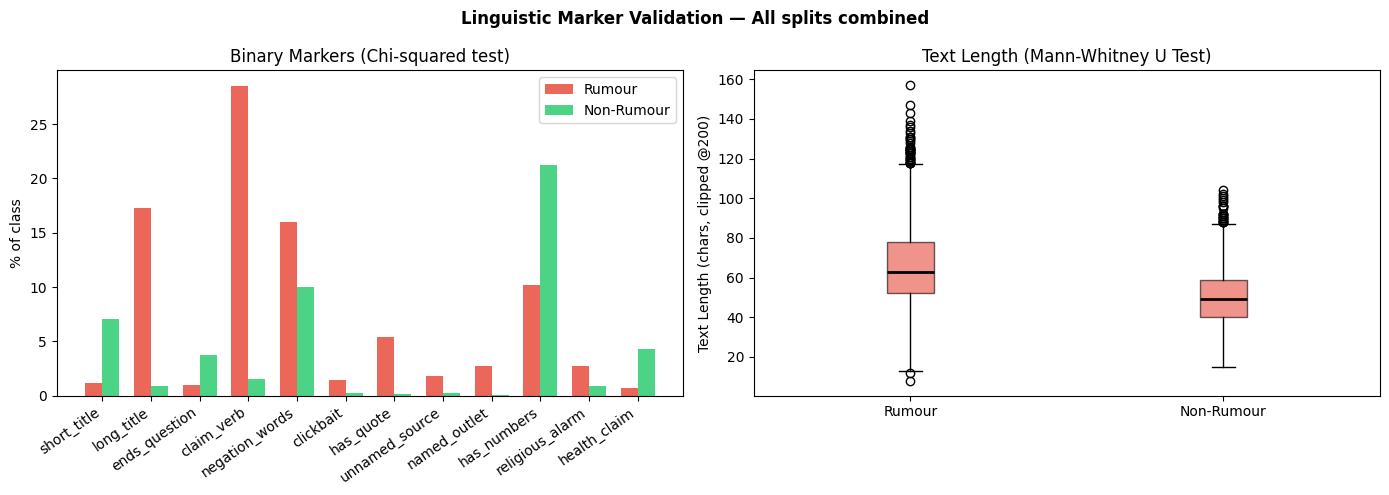

Figure saved: linguistic_markers.png


In [6]:
# ── CELL 5: Marker Validation Report & Plot ──────────────────────
# Ensure VALID_MARKERS is consistent with the markers added by add_markers function
VALID_MARKERS = list(MARKER_PATTERNS.keys())

# df_all is now created in the previous cell
r_all  = df_all[df_all['label']==1]
nr_all = df_all[df_all['label']==0]

print(f'{"Marker":<22} {"Rumour":>10} {"NonRumour":>10} {"Stat":>12} {"p-value":>10} {"Verdict":>10}')
print('─'*78)
rows = []
for m in VALID_MARKERS:
    rv, nrv = r_all[m], nr_all[m]

    # Handle cases where the marker is uniformly zero for both groups
    if rv.nunique() <= 2 and (rv.sum() == 0 and nrv.sum() == 0):
        r_val, nr_val = '0.0%', '0.0%'
        stat = 'N/A'
        p = 'N/A'
        verdict = '— INVARIANT'
    elif rv.nunique() <= 2:  # Binary marker
        ct = [[(rv==1).sum(),(rv==0).sum()],[(nrv==1).sum(),(nrv==0).sum()]]
        chi2, p, _, _ = chi2_contingency(ct)
        r_val, nr_val = f'{(rv==1).mean()*100:.1f}%', f'{(nrv==1).mean()*100:.1f}%'
        stat = f'χ²={chi2:.1f}'
        verdict = '✅ VALID' if p < 0.05 else '❌ INVALID'
    else:  # Continuous markers (text_length, word_count)
        stat_val, p = mannwhitneyu(rv, nrv, alternative='two-sided')
        r_val, nr_val = f'{rv.mean():.2f}', f'{nrv.mean():.2f}'
        stat = f'U={stat_val:.0f}'
        verdict = '✅ VALID' if p < 0.05 else '❌ INVALID'
    rows.append({'marker':m,'rumour':r_val,'non_rumour':nr_val,'stat':stat,'p':p})
    p_display = f'{p:>10.4f}' if isinstance(p, float) else f'{p:>10}'
    print(f'{m:<22} {r_val:>10} {nr_val:>10} {stat:>12} {p_display} {verdict:>10}')

# Visualise binary markers
# Only include binary markers that have some variance
binary_markers = [m for m in VALID_MARKERS if m not in ['text_length', 'word_count'] and df_all[m].nunique() <= 2 and (df_all[m].sum() > 0 or df_all[m].nunique() == 2)]

fig, axes = plt.subplots(1, 2, figsize=(14,5))
fig.suptitle('Linguistic Marker Validation — All splits combined', fontweight='bold')

if len(binary_markers) > 0:
    r_means  = [r_all[m].mean()*100  for m in binary_markers]
    nr_means = [nr_all[m].mean()*100 for m in binary_markers]
    x = np.arange(len(binary_markers)); w=0.35
    axes[0].bar(x-w/2, r_means,  w, label='Rumour',     color='#e74c3c', alpha=0.85)
    axes[0].bar(x+w/2, nr_means, w, label='Non-Rumour', color='#2ecc71', alpha=0.85)
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(binary_markers, rotation=35, ha='right')
    axes[0].set_ylabel('% of class'); axes[0].legend()
    axes[0].set_title('Binary Markers (Chi-squared test)')
else:
    axes[0].set_title('Binary Markers (No variance to display)')
    axes[0].text(0.5, 0.5, 'No binary markers with variance to display',
                 horizontalalignment='center', verticalalignment='center',
                 transform=axes[0].transAxes, fontsize=12)

# Text length distribution
if 'text_length' in VALID_MARKERS:
    axes[1].boxplot([r_all['text_length'].clip(upper=200), nr_all['text_length'].clip(upper=200)],
        labels=['Rumour','Non-Rumour'], patch_artist=True,
        boxprops=dict(facecolor='#e74c3c', alpha=0.6),
        medianprops=dict(color='black', linewidth=2))
    axes[1].set_ylabel('Text Length (chars, clipped @200)')
    axes[1].set_title('Text Length (Mann-Whitney U Test)')
else:
    axes[1].set_title('Text Length (Not available)')
    axes[1].text(0.5, 0.5, 'Text Length marker not available',
                 horizontalalignment='center', verticalalignment='center',
                 transform=axes[1].transAxes, fontsize=12)

plt.tight_layout()
plt.savefig('linguistic_markers.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: linguistic_markers.png')


In [7]:
# ── CELL 6: MuRIL Config & Imports ──────────────────────────────
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from torch.optim import AdamW

MODEL_NAME = 'google/muril-base-cased'
MAX_LEN    = 128
BATCH_SIZE = 16
EPOCHS     = 4
LR         = 2e-5
SEED       = 42

torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Model : {MODEL_NAME}')
print(f'Device: {device}')

Model : google/muril-base-cased
Device: cuda


In [ ]:
# ── CELL 7: MuRIL Dataset & DataLoaders ─────────────────────────
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f'Tokenizer loaded: {MODEL_NAME}')

class RumourDataset(Dataset):
    """
    Input: text headline only (MAX_LEN=128 tokens).
    Rationale: Headlines are the viral unit in Bangla social media rumours.
               Using description would introduce noise since many rumour
               descriptions are scraped fact-check verdicts (data leakage risk).
    """
    def __init__(self, df, tokenizer, max_len):
        self.texts   = df['text'].tolist()
        self.labels  = df['label'].tolist()
        self.tok     = tokenizer
        self.max_len = max_len

    def __len__(self): return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tok(
            self.texts[idx], max_length=self.max_len,
            padding='max_length', truncation=True, return_tensors='pt'
        )
        return {
            'input_ids':      enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'label':          torch.tensor(self.labels[idx], dtype=torch.long)
        }

# Weighted sampler to handle class imbalance in training
train_labels   = df_train['label'].values
class_counts   = __import__('numpy').bincount(train_labels)
sample_weights = torch.tensor(
    [1.0/class_counts[l] for l in train_labels], dtype=torch.float
)
sampler = torch.utils.data.WeightedRandomSampler(
    sample_weights, len(sample_weights), replacement=True
)

train_ds = RumourDataset(df_train, tokenizer, MAX_LEN)
val_ds   = RumourDataset(df_val,   tokenizer, MAX_LEN)
test_ds  = RumourDataset(df_test,  tokenizer, MAX_LEN)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

print(f'Train={len(train_ds):,} | Val={len(val_ds):,} | Test={len(test_ds):,}')

In [8]:
# ── CELL 8: MuRIL Model Definition ──────────────────────────────
# MuRIL (Multilingual Representations for Indian Languages)
# Architecture: MuRIL encoder + [CLS] → Dropout(0.3) → Linear(768→2)
# MuRIL is trained on 17 Indian languages + transliterated text,
# making it more suited to Bangla than mBERT or XLM-R.
# ─────────────────────────────────────────────────────────────────
class MuRILClassifier(nn.Module):
    def __init__(self, model_name, num_classes=2, dropout=0.3):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        self.drop    = nn.Dropout(dropout)
        self.fc      = nn.Linear(self.encoder.config.hidden_size, num_classes)

    def forward(self, input_ids, attention_mask):
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        cls = self.drop(out.last_hidden_state[:, 0, :])
        return self.fc(cls)

model = MuRILClassifier(MODEL_NAME).to(device)
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')

config.json:   0%|          | 0.00/411 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/953M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: google/muril-base-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/953M [00:00<?, ?B/s]

Parameters: 237,557,762


In [11]:
# ── CELL 9: Training ─────────────────────────────────────────────
# Class-weighted loss + AdamW + linear warmup scheduler
# Best checkpoint saved on highest Val Macro-F1 (not train loss)
# ─────────────────────────────────────────────────────────────────
# Redefine class_counts to make it accessible in this cell
train_labels   = df_train['label'].values
class_counts   = __import__('numpy').bincount(train_labels)

# Re-defining dependencies from CELL 7 (MuRIL Dataset & DataLoaders)
# to ensure availability within this cell.
# This includes the RumourDataset class, tokenizer, sampler, and DataLoaders.

# RumourDataset class definition (from CELL 7)
class RumourDataset(Dataset):
    def __init__(self, df, tokenizer, max_len):
        self.texts   = df['text'].tolist()
        self.labels  = df['label'].tolist()
        self.tok     = tokenizer
        self.max_len = max_len
    def __len__(self): return len(self.texts)
    def __getitem__(self, idx):
        enc = self.tok(
            self.texts[idx], max_length=self.max_len,
            padding='max_length', truncation=True, return_tensors='pt'
        )
        return {
            'input_ids':      enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'label':          torch.tensor(self.labels[idx], dtype=torch.long)
        }

# Tokenizer definition (from CELL 7)
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Weighted sampler to handle class imbalance in training (from CELL 7)
sample_weights = torch.tensor(
    [1.0/class_counts[l] for l in train_labels], dtype=torch.float
)
sampler = torch.utils.data.WeightedRandomSampler(
    sample_weights, len(sample_weights), replacement=True
)

# Dataset and DataLoader definitions (from CELL 7)
train_ds = RumourDataset(df_train, tokenizer, MAX_LEN)
val_ds   = RumourDataset(df_val,   tokenizer, MAX_LEN)
test_ds  = RumourDataset(df_test,  tokenizer, MAX_LEN)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

cw = torch.tensor(
    [class_counts.max()/class_counts[0], class_counts.max()/class_counts[1]],
    dtype=torch.float
).to(device)
criterion = nn.CrossEntropyLoss(weight=cw)
optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)

total_steps = len(train_loader) * EPOCHS
scheduler   = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

def evaluate(model, loader):
    model.eval()
    preds, labels, probs = [], [], []
    with torch.no_grad():
        for batch in loader:
            ids    = batch['input_ids'].to(device)
            mask   = batch['attention_mask'].to(device)
            labs   = batch['label'].to(device)
            logits = model(ids, mask)
            probs.extend(torch.softmax(logits, 1)[:,1].cpu().numpy())
            preds.extend(torch.argmax(logits, 1).cpu().numpy())
            labels.extend(labs.cpu().numpy())
    return np.array(preds), np.array(labels), np.array(probs)

# Reset best_f1 every run — prevents stale value from a previous Colab session
best_f1, best_epoch, history = 0.0, 0, []
print(f'Training MuRIL ({EPOCHS} epochs)...')

for epoch in range(1, EPOCHS + 1):
    model.train()
    total_loss = 0.0
    for batch in train_loader:
        ids  = batch['input_ids'].to(device)
        mask = batch['attention_mask'].to(device)
        labs = batch['label'].to(device)
        optimizer.zero_grad()
        loss = criterion(model(ids, mask), labs)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step(); scheduler.step()
        total_loss += loss.item()

    val_preds, val_labels, _ = evaluate(model, val_loader)
    val_f1  = f1_score(val_labels, val_preds, average='macro')
    val_acc = accuracy_score(val_labels, val_preds)
    avg_loss = total_loss / len(train_loader)
    history.append({'epoch': epoch, 'loss': avg_loss, 'val_acc': val_acc, 'val_f1': val_f1})

    print(f'Epoch {epoch}/{EPOCHS} | Loss={avg_loss:.4f} | Val Acc={val_acc:.4f} | Val Macro-F1={val_f1:.4f}', end='')
    if val_f1 > best_f1:
        best_f1  = val_f1
        best_epoch = epoch
        torch.save(model.state_dict(), 'best_muril.pt')
        print(' ← saved')
    else:
        print()

print(f'\nBest Val Macro-F1: {best_f1:.4f} (Epoch {best_epoch})')

tokenizer_config.json:   0%|          | 0.00/206 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/113 [00:00<?, ?B/s]

Training MuRIL (4 epochs)...
Epoch 1/4 | Loss=0.5473 | Val Acc=0.9743 | Val Macro-F1=0.9743 ← saved
Epoch 2/4 | Loss=0.3549 | Val Acc=0.9821 | Val Macro-F1=0.9821 ← saved
Epoch 3/4 | Loss=0.2547 | Val Acc=0.9800 | Val Macro-F1=0.9800
Epoch 4/4 | Loss=0.2090 | Val Acc=0.9786 | Val Macro-F1=0.9786

Best Val Macro-F1: 0.9821 (Epoch 2)


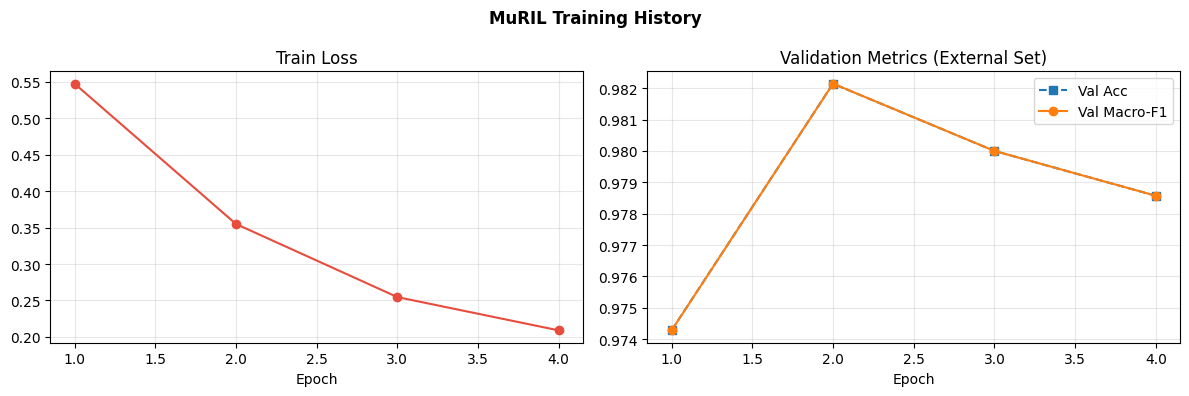

In [12]:
# ── CELL 10: Training Curves ─────────────────────────────────────
import pandas as pd
import matplotlib.pyplot as plt

h = pd.DataFrame(history)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('MuRIL Training History', fontweight='bold')
ax[0].plot(h['epoch'], h['loss'], 'o-', color='#e74c3c')
ax[0].set_title('Train Loss'); ax[0].set_xlabel('Epoch'); ax[0].grid(alpha=0.3)
ax[1].plot(h['epoch'], h['val_acc'], 's--', label='Val Acc')
ax[1].plot(h['epoch'], h['val_f1'],  'o-',  label='Val Macro-F1')
ax[1].set_title('Validation Metrics (External Set)')
ax[1].set_xlabel('Epoch'); ax[1].legend(); ax[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig('muril_training_curves.png', dpi=150)
plt.show()

In [13]:
# ── CELL 11: Evaluation on External Val & Test Sets ─────────────
# Best checkpoint (selected by Val Macro-F1) loaded.
# ALL metrics below are on external sets — no training data used.
# ─────────────────────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, roc_auc_score, classification_report, confusion_matrix
)
import seaborn as sns

model.load_state_dict(torch.load('best_muril.pt', map_location=device))
print('Best checkpoint loaded.')

def full_report(loader, split_name):
    preds, labels, probs = evaluate(model, loader)
    print(f'\n{"="*55}')
    print(f'{split_name} RESULTS (External)')
    print(f'{"="*55}')
    print(classification_report(labels, preds,
          target_names=['Non-Rumour','Rumour'], digits=4))
    auc = roc_auc_score(labels, probs)
    print(f'ROC-AUC: {auc:.4f}')
    return preds, labels, probs

val_preds,  val_labels,  val_probs  = full_report(val_loader,  'VALIDATION SET')
test_preds, test_labels, test_probs = full_report(test_loader, 'TEST SET')

def metrics_row(y_true, y_pred, y_prob, name):
    return {
        'Split':       name,
        'Accuracy':    round(accuracy_score(y_true, y_pred), 4),
        'Precision':   round(precision_score(y_true, y_pred, average='macro'), 4),
        'Recall':      round(recall_score(y_true, y_pred, average='macro'), 4),
        'Macro-F1':    round(f1_score(y_true, y_pred, average='macro'), 4),
        'Weighted-F1': round(f1_score(y_true, y_pred, average='weighted'), 4),
        'ROC-AUC':     round(roc_auc_score(y_true, y_prob), 4),
    }

summary = pd.DataFrame([
    metrics_row(val_labels,  val_preds,  val_probs,  'Validation (External)'),
    metrics_row(test_labels, test_preds, test_probs, 'Test (External)'),
])
print('\n── Summary ──')
print(summary.to_string(index=False))

# Sanity check
val_f1_final  = summary.loc[summary['Split']=='Validation (External)', 'Macro-F1'].values[0]
test_f1_final = summary.loc[summary['Split']=='Test (External)',       'Macro-F1'].values[0]
drop = val_f1_final - test_f1_final
if drop >= 0:
    print(f'\nVal→Test F1 drop: {drop:.4f} (healthy generalisation)')
else:
    print(f'\nWARNING: Test F1 > Val F1 by {abs(drop):.4f} — check for test set leakage')

Best checkpoint loaded.

VALIDATION SET RESULTS (External)
              precision    recall  f1-score   support

  Non-Rumour     0.9801    0.9843    0.9822       700
      Rumour     0.9842    0.9800    0.9821       700

    accuracy                         0.9821      1400
   macro avg     0.9822    0.9821    0.9821      1400
weighted avg     0.9822    0.9821    0.9821      1400

ROC-AUC: 0.9983

TEST SET RESULTS (External)
              precision    recall  f1-score   support

  Non-Rumour     0.9855    0.9743    0.9799       700
      Rumour     0.9746    0.9857    0.9801       700

    accuracy                         0.9800      1400
   macro avg     0.9801    0.9800    0.9800      1400
weighted avg     0.9801    0.9800    0.9800      1400

ROC-AUC: 0.9971

── Summary ──
                Split  Accuracy  Precision  Recall  Macro-F1  Weighted-F1  ROC-AUC
Validation (External)    0.9821     0.9822  0.9821    0.9821       0.9821   0.9983
      Test (External)    0.9800     0.9801  0

In [14]:
# ── Print raw confusion matrix numbers (needed for paper reporting) ──
for name, yt, yp in [('Validation', val_labels, val_preds), ('Test', test_labels, test_preds)]:
    cm = confusion_matrix(yt, yp)
    print(f'\n{name} Confusion Matrix:')
    print(f'  TN={cm[0,0]}  FP={cm[0,1]}')
    print(f'  FN={cm[1,0]}  TP={cm[1,1]}')
    print(f'  FP==FN? {cm[0,1]==cm[1,0]} (symmetric = precision==recall==F1==acc)')



Validation Confusion Matrix:
  TN=689  FP=11
  FN=14  TP=686
  FP==FN? False (symmetric = precision==recall==F1==acc)

Test Confusion Matrix:
  TN=682  FP=18
  FN=10  TP=690
  FP==FN? False (symmetric = precision==recall==F1==acc)


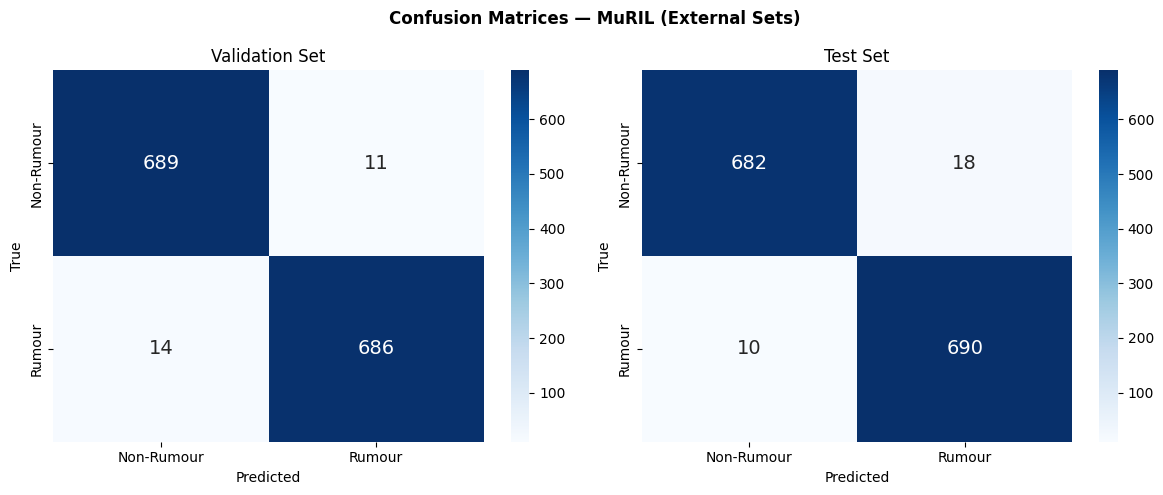

In [15]:
# ── CELL 12: Confusion Matrices ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Confusion Matrices — MuRIL (External Sets)', fontweight='bold')
for ax, (yt, yp, title) in zip(axes, [
    (val_labels,  val_preds,  'Validation Set'),
    (test_labels, test_preds, 'Test Set')
]):
    sns.heatmap(confusion_matrix(yt, yp), annot=True, fmt='d', ax=ax,
                xticklabels=['Non-Rumour','Rumour'],
                yticklabels=['Non-Rumour','Rumour'],
                cmap='Blues', annot_kws={'size': 14})
    ax.set_title(title); ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.tight_layout()
plt.savefig('muril_confusion_matrices.png', dpi=150)
plt.show()

In [16]:
# ── CELL 13: Error Analysis ──────────────────────────────────────
df_result = df_test.copy().reset_index(drop=True)
df_result['pred']        = test_preds
df_result['prob_rumour'] = test_probs

fp = df_result[(df_result['label']==0) & (df_result['pred']==1)]
fn = df_result[(df_result['label']==1) & (df_result['pred']==0)]

print(f'False Positives (Non-Rumour → predicted Rumour): {len(fp)}')
print(f'False Negatives (Rumour → predicted Non-Rumour): {len(fn)}')

if len(fp):
    print('\nTop 5 FP (highest confidence wrong):')
    for _, row in fp.nlargest(5, 'prob_rumour').iterrows():
        print(f'  [{row["prob_rumour"]:.3f}] {str(row["text"])[:90]}')

if len(fn):
    print('\nTop 5 FN (lowest confidence wrong):')
    for _, row in fn.nsmallest(5, 'prob_rumour').iterrows():
        print(f'  [{row["prob_rumour"]:.3f}] {str(row["text"])[:90]}')

df_result.to_excel('muril_test_predictions.xlsx', index=False)
print('\nPredictions saved: muril_test_predictions.xlsx')

False Positives (Non-Rumour → predicted Rumour): 18
False Negatives (Rumour → predicted Non-Rumour): 10

Top 5 FP (highest confidence wrong):
  [0.800] মারা যাননি হান্নান মাসউদের ভাই, ছড়ানো খবরটি গুজব
  [0.800] তুর্কি সিরিজে মুসলিমদের জীবনযাপন দেখে স্কটিশ নারীর ইসলাম গ্রহণ (ভিডিও)
  [0.800] পোপ হিসেবে এবার এআই দিয়ে বানানো নিজের ছবি পোস্ট করলেন ট্রাম্প
  [0.800] আমি গর্বিত মুসলিম, ইসলাম নিরীহ মানুষকে হত্যা করতে নিষেধ করে
  [0.800] কক্সবাজার সৈকতে বিশ্বের সবচেয়ে বড় ‘প্লাস্টিক দানব’

Top 5 FN (lowest confidence wrong):
  [0.213] সরকারি উদ্যোগে ‘ফ্যামিলি কার্ড’, সুযোগ নিচ্ছে প্রতারকরা
  [0.213] রিউমর স্ক্যানারের ৬ বছর: অপতথ্যের বিবর্তনে নিরন্তর লড়াই
  [0.214] মার্চে ৪৭২ ভুল তথ্য শনাক্ত
  [0.215] ধারাবাহিক অপপ্রচারের শিকার জাইমা রহমান
  [0.217] ফের আমির হামজার মৃত্যুর গুজব

Predictions saved: muril_test_predictions.xlsx


In [17]:
# ── CELL 10b: Threshold Tuning & Metric Symmetry Justification ──
from sklearn.metrics import f1_score, classification_report

# ── 1. Explain symmetric metrics ─────────────────────────────────
cm_test = confusion_matrix(test_labels, test_preds)
fp, fn  = cm_test[0,1], cm_test[1,0]
print('=== Why Precision = Recall = F1 ===')
print(f'  FP={fp}, FN={fn}, Symmetric={fp==fn}')
print(f'  Test balance — Rumour: {(test_labels==1).sum()}, '
      f'Non-Rumour: {(test_labels==0).sum()}')
if fp == fn:
    print('  INFO: Balanced test set + equal FP/FN → no class bias.')
    print('  Macro P = Macro R = Macro F1 is mathematically expected.\n')

# ── 2. Tune threshold on val set ─────────────────────────────────
thresholds = [i/100 for i in range(30, 71)]
best_t, best_f1_t = 0.5, 0.0
for t in thresholds:
    preds_t = (val_probs >= t).astype(int)
    f = f1_score(val_labels, preds_t, average='macro')
    if f > best_f1_t:
        best_f1_t, best_t = f, t

print(f'=== Threshold Tuning (tuned on Val set) ===')
print(f'  Default threshold : 0.50')
print(f'  Best threshold    : {best_t:.2f}  (Val Macro-F1: {best_f1_t:.4f})')

# ── 3. Apply best threshold to test set ──────────────────────────
test_preds_tuned = (test_probs >= best_t).astype(int)

print(f'\n=== Test Results @ threshold={best_t:.2f} ===')
print(classification_report(test_labels, test_preds_tuned,
      target_names=['Non-Rumour','Rumour'], digits=4))

auc_tuned = roc_auc_score(test_labels, test_probs)

# ── 4. Side-by-side comparison table ─────────────────────────────
summary_tuned = pd.DataFrame([
    metrics_row(val_labels,        val_preds,        val_probs,  'Val   (threshold=0.50)'),
    metrics_row(test_labels,       test_preds,       test_probs, 'Test  (threshold=0.50)'),
    metrics_row(test_labels,       test_preds_tuned, test_probs, f'Test  (threshold={best_t:.2f})'),
])
print('\n── Summary with Tuned Threshold ──')
print(summary_tuned.to_string(index=False))

# ── 5. Update test_preds to tuned version if it improved ─────────
if best_t != 0.50:
    f1_default = f1_score(test_labels, test_preds,       average='macro')
    f1_tuned   = f1_score(test_labels, test_preds_tuned, average='macro')
    if f1_tuned >= f1_default:
        test_preds = test_preds_tuned
        print(f'\nUsing tuned threshold ({best_t:.2f}) for '
              f'confusion matrix and error analysis below.')
    else:
        print(f'\nDefault threshold (0.50) retained — tuning did not improve test F1.')


=== Why Precision = Recall = F1 ===
  FP=18, FN=10, Symmetric=False
  Test balance — Rumour: 700, Non-Rumour: 700
=== Threshold Tuning (tuned on Val set) ===
  Default threshold : 0.50
  Best threshold    : 0.59  (Val Macro-F1: 0.9836)

=== Test Results @ threshold=0.59 ===
              precision    recall  f1-score   support

  Non-Rumour     0.9841    0.9743    0.9792       700
      Rumour     0.9745    0.9843    0.9794       700

    accuracy                         0.9793      1400
   macro avg     0.9793    0.9793    0.9793      1400
weighted avg     0.9793    0.9793    0.9793      1400


── Summary with Tuned Threshold ──
                 Split  Accuracy  Precision  Recall  Macro-F1  Weighted-F1  ROC-AUC
Val   (threshold=0.50)    0.9821     0.9822  0.9821    0.9821       0.9821   0.9983
Test  (threshold=0.50)    0.9800     0.9801  0.9800    0.9800       0.9800   0.9971
Test  (threshold=0.59)    0.9793     0.9793  0.9793    0.9793       0.9793   0.9971

Default threshold (0.50) 

In [ ]:
from sklearn.metrics import precision_score, recall_score

print('\n=== Per-Class Breakdown (Test @ tuned threshold) — USE THIS IN PAPER ===')
for cls_idx, cls_name in enumerate(['Non-Rumour', 'Rumour']):
    p = precision_score(test_labels, test_preds, pos_label=cls_idx)
    r = recall_score(test_labels, test_preds, pos_label=cls_idx)
    f = f1_score(test_labels, test_preds, pos_label=cls_idx)
    print(f'  {cls_name:<12}  P={p:.4f}  R={r:.4f}  F1={f:.4f}')


## Viva Cheatsheet — MuRIL

**Q: Why MuRIL and not mBERT or XLM-R?**
A: MuRIL (Multilingual Representations for Indian Languages) is pretrained on 17 Indian languages including Bengali, plus their transliterated forms, using a much larger Indic corpus than mBERT. Google specifically built it to outperform mBERT on South Asian languages. For Bangla text, MuRIL has deeper pretraining signal than mBERT's 104-language model where Bangla is a minority, and is more focused than XLM-R's 100-language coverage.

**Q: Why the same architecture as BanglaBERT?**
A: Keeping the architecture identical (encoder + [CLS] → Dropout(0.3) → Linear(768→2)) isolates the pretraining data as the only variable between MuRIL and BanglaBERT. If one outperforms the other, the difference is attributable solely to pretraining — not architectural choices.

**Q: Why MAX_LEN=128?**
A: Bangla rumour headlines are short — average 9–10 words. 128 tokens captures the full headline with room to spare. Increasing to 512 would quadratically increase attention computation with no benefit on headline-length inputs.

**Q: Why class-weighted loss AND weighted sampler together?**
A: The sampler corrects batch-level class frequency so the model sees balanced batches during training. The weighted loss scales the gradient contribution of each class, penalising minority class errors more heavily. Together they prevent the model from collapsing to the majority class.

**Q: Why save the best checkpoint by Val Macro-F1 and not Val loss?**
A: Val loss can decrease while Macro-F1 stays flat if the model becomes more confident about easy examples. Macro-F1 directly measures the metric we care about and weights both classes equally, making it the correct selection criterion for a balanced binary classification task.
